# Prueba Ji Cuadrada: La primera prueba de bondad de ajuste

Durante el siglo XIX, mientras Pearson realizaba estudios sobre la herencia genética y las leyes de Mendel, surgió la necesidad de una herramienta estadística para evaluar el ajuste de los datos a un modelo teórico. Fue así como se desarrolló la prueba Ji Cuadrada, el primer método de bondad de ajuste formalmente reconocido.

Como toda prueba de bondad de ajuste, se busca comparar los datos observados contra los datos que se esperarían observar bajo una distribución teórica específica, y si difieren por mucho, hay evidencia en contra de que los datos sigan esa distribución. 

Esta prueba se basa en comparar las frecuencias observadas contra las frecuencias esperadas. Esto quiere decir que se asume un espacio de categorías o clases (mutuamente excluyentes y exhaustivas) y se cuenta cuántos datos caen en cada categoría (frecuencias observadas) y se calcula cuántos datos se esperarían en cada categoría bajo la distribución teórica (frecuencias esperadas). Este proceso puede generar pérdida de información pues se agrupan los datos en las categorías. 

Para un mejor uso de la prueba, se recomienda utilizar en variables categóricas o discretas, porque aplicar a variables continuas puede generar conclusiones erróneas debido a la pérdida de información al agrupar los datos en categorías.

## Formulación de la hipótesis

La prueba Ji Cuadrada se puede formular de dos formas:  

### Especificando la distribución teórica
$$
H_0: X \sim D(\theta)  \qquad H_1: X \not\sim D(\theta)
$$

En este escenario, las categorías no están dadas previamente, y se asignan de forma arbitaria. Algunos autores sugieren que se asignen de forma equitativa, es decir, con la misma cantidad de datos en cada categoría. Sin embargo, esto no es necesario, y se pueden asignar las categorías de acuerdo a criterios específicos del problema.



### Especificando las probabilidades de cada categoría
$$
H_0: p_i = \pi_i, \quad i = 1, 2, \ldots, k \qquad H_1: \text{al menos una } p_i \neq \pi_i
$$

Condiciones:

- $\sum_{i=1}^{k} \pi_i = 1 $
- $\sum_{i=1}^{k} e_i = n = \sum_{i=1}^{k} O_i$ pero no necesariamente $e_i = O_i$ para cada $i$.


En este caso, las categorías están dadas previamente, por lo que no hay pérdida de información al asignar los datos a las categorías. Sin embargo, es necesario especificar las probabilidades de cada categoría bajo la hipótesis nula, lo cual puede ser difícil en algunos casos.

## Procedimiento

1. Definir las categorías o clases $(C_i)$ en las que se agruparán los datos.
2. Contar las frecuencias observadas $(O_i)$ en cada categoría.
3. Calcular las probabilidades inducidas por $H_0$ para cada categoría. 

$$
\pi_i = P(X \in C_{i} | H_0) = P(X \in C_{i} | X \sim D(\theta))
$$

3. Calcular las frecuencias esperadas $(e_i = n \pi_i)$ bajo $H_0$
4. Calcular el estadístico de prueba:
   $$
   \sum_{i=1}^{k} \frac{(O_i - e_i)^2}{e_i} \quad \sim \chi^2_{k-1}
   $$
   donde $k$ es el número de categorías.

5. Calcular el cuantil de orden $1 - \alpha$ de la distribución $\chi^2$ con $k-1$ grados de libertad

6. Hay evidencia en contra de $H_0$ si el estadístico de prueba es mayor que el cuantil calculado en el paso anterior, o si el p-value es menor que $\alpha$.

## Limitaciones

- Conclusiones erróneas al aplicar a variables continuas debido a la pérdida de información al agrupar los datos en categorías.
- Requiere un tamaño de muestra $n \geq 20 $ 
- Cada categoría debe tener una frecuencia observada de al menos $5$ (si no, se pueden agrupar categorías para cumplir esta condición).

## Ejemplo variable continua

Para ilustrar la aplicación de la prueba Ji Cuadrada a una variable continua, consideremos el siguiente ejemplo:



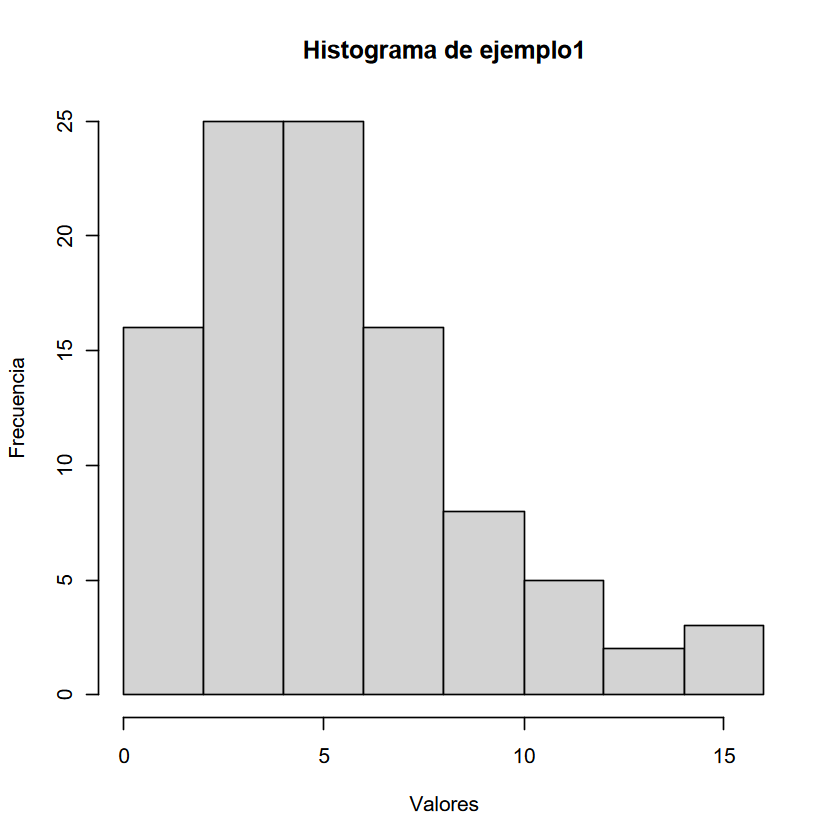

In [17]:
set.seed(123)

ejemplo1<- rgamma(100, shape = 2, scale = 3)
hist(ejemplo1, breaks = 10, main = "Histograma de ejemplo1", xlab = "Valores", ylab = "Frecuencia")






In [18]:
library(fitdistrplus)

modelo_gamma <- fitdist(ejemplo1, "gamma")
summary(modelo_gamma)

modelo_exp <- fitdist(ejemplo1, "exp")
summary(modelo_exp)



Cargando paquete requerido: MASS


Adjuntando el paquete: 'MASS'


The following object is masked from 'package:dplyr':

    select


Cargando paquete requerido: survival



Fitting of the distribution ' gamma ' by maximum likelihood 
Parameters : 
       estimate Std. Error
shape 2.1928550 0.28963050
rate  0.4245613 0.06297949
Loglikelihood:  -249.8111   AIC:  503.6222   BIC:  508.8325 
Correlation matrix:
          shape      rate
shape 1.0000000 0.8903723
rate  0.8903723 1.0000000


Fitting of the distribution ' exp ' by maximum likelihood 
Parameters : 
      estimate Std. Error
rate 0.1936296 0.01936245
Loglikelihood:  -264.1808   AIC:  530.3616   BIC:  532.9668 

$ H_0: X \sim Exp(\lambda_{MV})  \quad H_1: X \not\sim Exp(\lambda_{MV})$

In [ ]:
# x vector de datos
# p probabilidades
# rescale.p para que sume 1 las prbas

chisq.test(x = ejemplo1,p = dexp(ejemplo1, rate = modelo_exp$estimate),rescale.p = TRUE)
 


Warning message in chisq.test(x = ejemplo1, p = dexp(ejemplo1, rate = modelo_exp$estimate), :
"Chi-squared approximation may be incorrect"



	Chi-squared test for given probabilities

data:  ejemplo1
X-squared = 2009.2, df = 99, p-value < 2.2e-16


[1] 0.11532336 0.02827935 0.17805303 0.07371497 0.01560019 0.05659088
  [7] 0.15794063 0.17950432 0.02728002 0.06154855 0.05951114 0.07474562
 [13] 0.11503013 0.02528002 0.04078523 0.08424935 0.10978404 0.09382415
 [19] 0.14426933 0.08599832 0.17794037 0.15240574 0.15083951 0.10022714
 [25] 0.09868132 0.08861046 0.04093901 0.04633136 0.05224669 0.08461434
 [31] 0.06528925 0.15549376 0.09334075 0.09068015 0.02775223 0.14997366
 [37] 0.05937033 0.13579546 0.08587705 0.10722510 0.08350001 0.06583655
 [43] 0.14563486 0.17210840 0.14688028 0.06900731 0.06055745 0.11164715
 [49] 0.00896954 0.16163800 0.06441149 0.05720065 0.07798344 0.03714958
 [55] 0.01023439 0.11093436 0.13667922 0.12472688 0.04932031 0.08137092
 [61] 0.15550517 0.12934810 0.08068141 0.06027713 0.10337515 0.12845467
 [67] 0.06296536 0.03117347 0.05782987 0.10059150 0.06951948 0.11080133
 [73] 0.06779536 0.11959077 0.02534764 0.10920216 0.01935867 0.09503383
 [79] 0.07074191 0.01443525 0.07885404 0.02869977 0.11520062 0.08362596
 [85] 0.05701690 0.05348905 0.09470171 0.11626442 0.05541735 0.09687449
 [91] 0.05383414 0.06453388 0.07502413 0.12040052 0.03573036 0.03969523
 [97] 0.05862693 0.06255033 0.05033164 0.01286632

Rechaza la distribución verdadera.

In [48]:
chisq.test(x = ejemplo1,p = dgamma(ejemplo1, shape= modelo_gamma$estimate[1],rate = modelo_gamma$estimate[2]),rescale.p = TRUE )

Warning message in chisq.test(x = ejemplo1, p = dgamma(ejemplo1, shape = modelo_gamma$estimate[1], :
"Chi-squared approximation may be incorrect"



	Chi-squared test for given probabilities

data:  ejemplo1
X-squared = 3378, df = 99, p-value < 2.2e-16


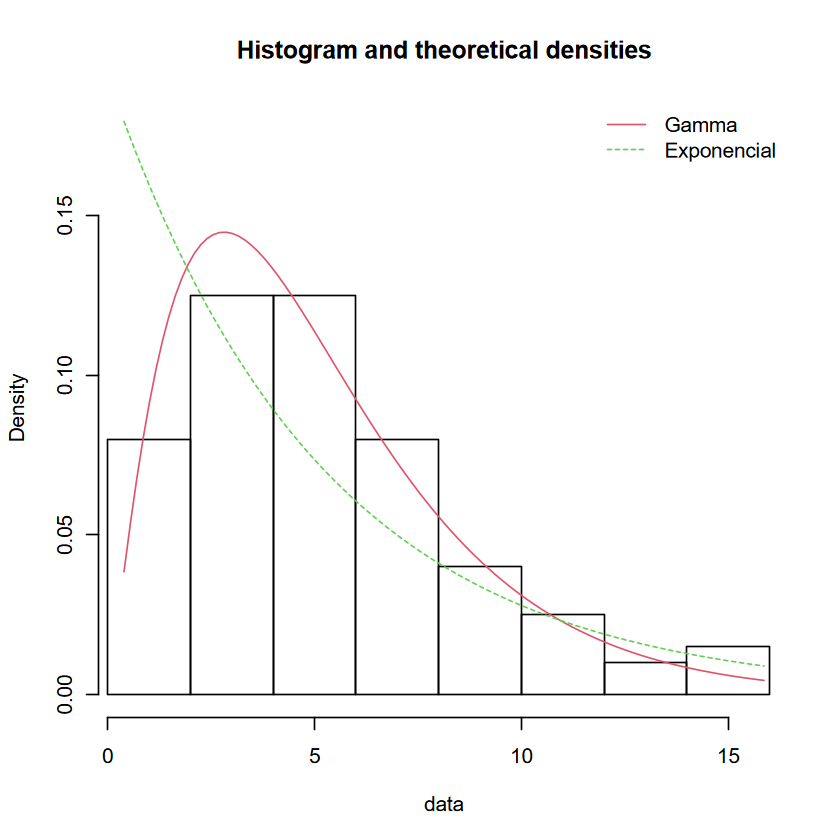

In [49]:
denscomp(list(modelo_gamma, modelo_exp), legendtext = c("Gamma", "Exponencial"))


## Ejemplo: Satisfacción del sevicio hospitalario en CDMX

En los hospitales de la CDMX se desea evaluar la calidad del servicio hospitalario, expertos sugieren que basta con preguntar acerca del grado de satisfacción de los pacientes con respecto al sevicio de los doctores. 


Este estudio permitirá identificar la situación actual del servicio en CDMX, para que posteriormente se implementen medidas para mejorar el servicio.



Se pregunta a los pacientes ¿Qué tan satisfecho está con el servicio del doctor? Las posibles respuestas son: 

1. Insatisfecho con el servicio.
2. Conforme con el servicio.
3. Muy agradecido con el servicio. 


Para asignar una evaluación a cada hospital, se consideran 3 tipos de hospitales:

- Hospital con mal servicio: 50% insatisfecho con el servicio, 30 % conforme y 20% muy agradecido.

- Hospital con servicio regular: 35% insatisfecho con el servicio, 45 % conforme y 20% muy agradecido.

- Hospital con excelente servicio: 20% insatisfecho con el servicio, 45 % conforme y 35% muy agradecido.


Se tiene las respuestas de pacientes de 3 clinicas clave en la CDMX. Sucursal Centro, Sucursal Norte y Sucursal Sur, y se desea verificar el tipo de hospital que son.





Los tipos de hospitales se ven como:

## Tablas de Contingencia

Una generalización de la prueba Ji Cuadrada son las tablas de contingencia, que plantean el siguiente contraste de hipótesis:

$$
H_0: \text{Las variables X y Y son independientes} \qquad vs \qquad H_1: \text{Las variables X y Y no son independientes}
$$

Las variables deben ser al menos ordinales, y debe trabajar con las frecuencias observadas de cada combinación de categorías de las variables.

Si tenemos dos variables 

$$
X = \begin{cases}
x_1 \\
x_2 \\
\vdots \qquad \text{(k categorías)} \\
\vdots\\
x_k
\end{cases}

\qquad \quad
 
Y = \begin{cases}
y_1 \\
y_2 \\
\vdots \qquad \text{(r categorías)} \\
\vdots\\
y_r
\end{cases}

$$ 

Entonces se puede construir una tabla de contingencia con $k$ filas y $r$ columnas, donde cada celda $(i,j)$ contiene la frecuencia observada de la combinación de categorías $x_i$ y $y_j$.


|        | $y_1$      | $y_2$      | $\cdots$ | $y_j$      | $\cdots$ | $y_{r-1}$   | $y_r$      | Total fila |
|--------|------------|------------|----------|------------|----------|-------------|------------|------------|
| $x_1$  | $n_{11}$   | $n_{12}$   | $\cdots$ | $n_{1j}$   | $\cdots$ | $n_{1,r-1}$ | $n_{1r}$   | $n_{1\cdot}$ |
| $x_2$  | $n_{21}$   | $n_{22}$   | $\cdots$ | $n_{2j}$   | $\cdots$ | $n_{2,r-1}$ | $n_{2r}$   | $n_{2\cdot}$ |
| $\vdots$ | $\vdots$ | $\vdots$   | $\ddots$ | $\vdots$   | $\ddots$ | $\vdots$    | $\vdots$   | $\vdots$   |
| $x_i$  | $n_{i1}$   | $n_{i2}$   | $\cdots$ | $n_{ij}$   | $\cdots$ | $n_{i,r-1}$ | $n_{ir}$   | $n_{i\cdot}$ |
| $\vdots$ | $\vdots$ | $\vdots$   | $\ddots$ | $\vdots$   | $\ddots$ | $\vdots$    | $\vdots$   | $\vdots$   |
| $x_{k-1}$ | $n_{k-1,1}$ | $n_{k-1,2}$ | $\cdots$ | $n_{k-1,j}$ | $\cdots$ | $n_{k-1,r-1}$ | $n_{k-1,r}$ | $n_{k-1\cdot}$ |
| $x_k$  | $n_{k1}$   | $n_{k2}$   | $\cdots$ | $n_{kj}$   | $\cdots$ | $n_{k,r-1}$ | $n_{kr}$   | $n_{k\cdot}$ |
| Total columna | $n_{\cdot 1}$ | $n_{\cdot 2}$ | $\cdots$ | $n_{\cdot j}$ | $\cdots$ | $n_{\cdot,r-1}$ | $n_{\cdot r}$ | $n$ |


Esto sugiere con naturalidad la siguiente formulación de la prueba:

$$
H_0: P(X = x_i, Y = y_j) = P(X = x_i)P(Y = y_j) \quad \forall i,j

\qquad vs \qquad H_1: \text{al menos una } P(X = x_i, Y = y_j) \neq P(X = x_i)P(Y = y_j)
$$

Como ambas son densidades de probabilidad, solo necesito conocer las probabilidades de $k-1$ categorías de $X$ y $r-1$ categorías de $Y$, por lo que la formulación de la hipótesis nula se puede escribir como:

$$
H_0: P_{ij} = P_{i\cdot}P_{\cdot j} \quad \forall i \in \{1, \ldots, k-1\}, j \in \{1, \ldots, r-1\}

\qquad vs \qquad H_1: \text{al menos una } P_{ij} \neq P_{i\cdot}P_{\cdot j}

$$


Y la estadística de prueba se calcula como:

$$
T = \sum_{i=1}^{k} \sum_{j=1}^{r} \frac{(n_{ij} - e_{ij})^2}{e_{ij}} \quad \sim \chi^2_{(k-1)(r-1)} 
$$

Se rechaza la hipótesis nula si $T > \chi^{2, 1-\alpha}_{(k-1)(r-1)}$ o si el p-value es menor que $\alpha$.








## Observaciones:

- Rechazar la hipótesis nula implica que existe una dependencia entre ellas (no necesariamente una correlación). 

- La noción de dependencia se refiere a que el resultado de una variable influye en el resultado de la otra variable. Y por ello $P(X,Y)=P(Y|X)P(X)$. 

- La noción de correlación se refiere a que la relación entre las variables es monótona. 

- Claramente la idea de dependencia es más general que la idea de correlación, pues las variables pueden tener una relación no monótona (correlación $\approx 0$), pero aún así ser dependientes.



## Ejemplo: Factores psicoeducativos asociados a la participación y aspiraciones de posgrado en estudiantes de licenciatura

Se desea analizar algunos factores psicoeducativos asociados a la participación y aspiraciones de posgrado en estudiantes de licenciatura, con el objetivo de identificar posibles áreas de intervención para mejorar la participación y aspiraciones de posgrado en esta población.


Para ello, se realiza una encuesta a 21 estudiantes de licenciatura, donde se les pregunta acerca de su participación en clases, percepción sobre su nivel de estrés, desempeño de sus profesores, sus aspiraciones de posgrado así como el grado de escolaridad de sus padres.




In [8]:
datos <- read.csv("Factores_psicoeducativos_limpio.csv")

head(datos)
 
colnames(datos) <- c("escolaridad_padres", "ansiedad","estres","participacion","profesores", "posgrado")


datos$participacion <- factor(
  datos$participacion, levels = c("Nunca", "Casi nunca", "A veces", "Frecuentemente")
)

datos$profesores <- factor(
  datos$profesores, levels = c("Insatisfech@", "Neutral", "Satisfech@", "Muy satisfech@")
)

head(datos)


,Nivel.educativo.más.alto.de.tus.padres.,X.Consideras.que.tienes.ansiedad.social...A.qué.nivel.,El.nivel.de.estrés.que.la.escuela..entregar.tareas..exámenes..clases..te.genera.,X.Con.qué.frecuencia.participas.en.tus.clases.,X.Qué.tan.satisfech..estás.con.los.profesores.que.has.tenido.durante.tu.estancia.en.la.Facultad.,X.Tienes.interés.en.realizar.un.posgrado...Sin.importar.el.enfoque.
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Preparatoria,Moderada,Bajo,A veces,Satisfech@,Nada
2,Secundaria,Baja,Alto,A veces,Neutral,Interesad@
3,Preparatoria,Moderada,Alto,A veces,Insatisfech@,Poco
4,Licenciatura,Nula,Moderado,Casi nunca,Satisfech@,Interesad@
5,Posgrado,Baja,Moderado,A veces,Satisfech@,Interesad@
6,Preparatoria,Moderada,Muy alto,Nunca,Satisfech@,Interesad@


,escolaridad_padres,ansiedad,estres,participacion,profesores,posgrado
,<chr>,<chr>,<chr>,<fct>,<fct>,<chr>
1,Preparatoria,Moderada,Bajo,A veces,Satisfech@,Nada
2,Secundaria,Baja,Alto,A veces,Neutral,Interesad@
3,Preparatoria,Moderada,Alto,A veces,Insatisfech@,Poco
4,Licenciatura,Nula,Moderado,Casi nunca,Satisfech@,Interesad@
5,Posgrado,Baja,Moderado,A veces,Satisfech@,Interesad@
6,Preparatoria,Moderada,Muy alto,Nunca,Satisfech@,Interesad@


Enfocandose en los efectos de la interacción en el aula, se tienen 3 tipos de salones que el estudio abarca:



- Salón apático: Predomina la no participación.

50% Nunca, 15% Casi nunca, 25% A veces, 10% Frecuentemente

- Salón regular: Participación intermedia con ligera inclinación a baja participación.

30% Nunca, 20% Casi nunca, 30% A veces, 20% Frecuentemente

- Salón participativo: Alta participación sostenida.

10% Nunca, 20% Casi nunca, 30% A veces, 40% Frecuentemente

Primero visualizando cada modelo teórico:



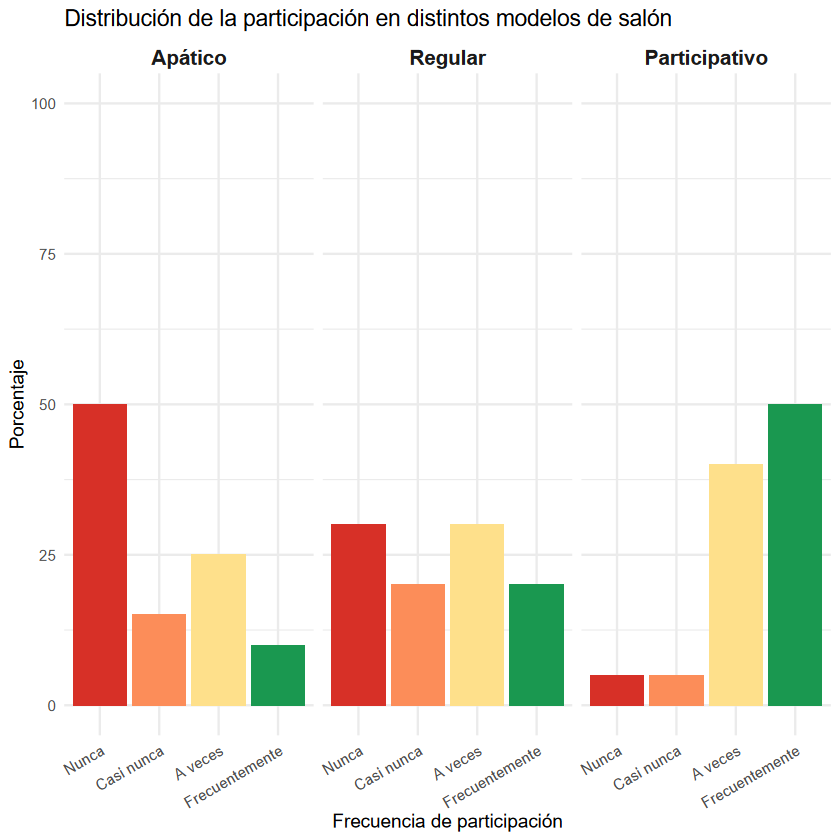

In [ ]:
library(ggplot2)
library(dplyr)

modelos_teoricos <- data.frame(
  salon = rep(c("Apático", "Regular", "Participativo"), each = 4),
  participacion = rep(c("Nunca", "Casi nunca", "A veces", "Frecuentemente"), times = 3),
  porcentaje = c(
    50, 15, 25, 10,  
    30, 20, 30, 20,   
    5,  5,  40, 50    
  )
)

# factores
modelos_teoricos$participacion <- factor(
  modelos_teoricos$participacion,
  levels = c("Nunca", "Casi nunca", "A veces", "Frecuentemente")
)

modelos_teoricos$salon <- factor(
  modelos_teoricos$salon,
  levels = c("Apático", "Regular", "Participativo")
)

ggplot(modelos_teoricos, aes(x = participacion, y = porcentaje, fill = participacion)) +
  geom_bar(stat = "identity") +
  facet_wrap(~ salon) +
  ylim(0, 100) +
  labs(
    title = "Distribución de la participación en distintos modelos de salón",
    x = "Frecuencia de participación",
    y = "Porcentaje"
  ) +
  scale_fill_manual(values = c("#d73027", "#fc8d59", "#fee08b", "#1a9850")) +
  theme_minimal() +
  theme(
    legend.position = "none",
    strip.text = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(angle = 30, hjust = 1)
  )

Visualizando mis datos:


participacion,n
<fct>,<int>
Nunca,3
Casi nunca,6
A veces,9
Frecuentemente,4


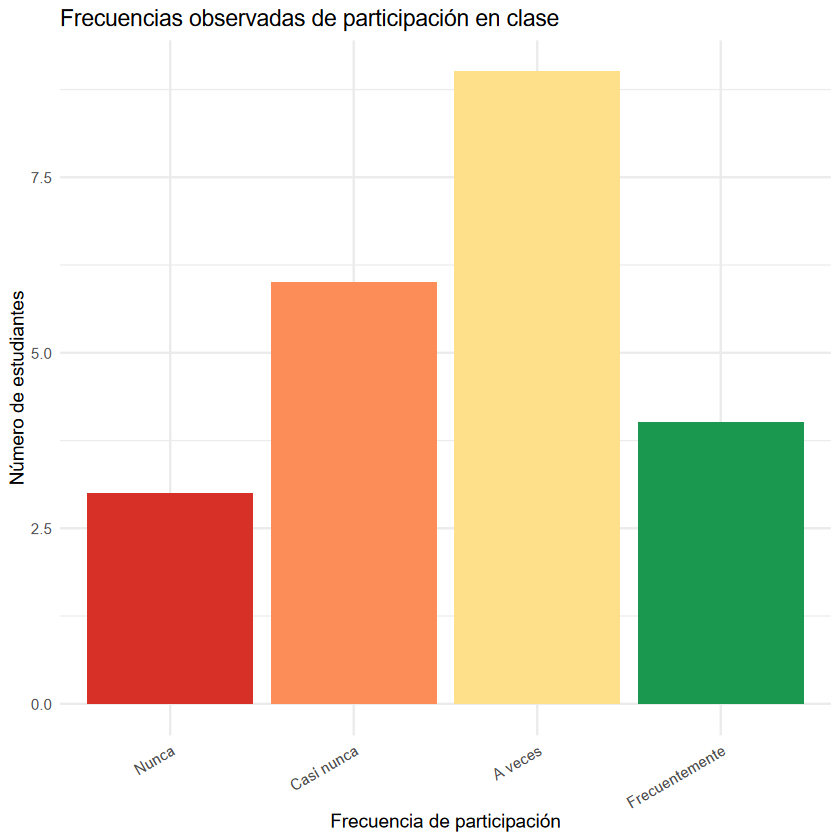

In [9]:
library(dplyr)
library(ggplot2)

obs <- datos %>%
  count(participacion) %>%
  arrange(participacion)

obs$participacion <- factor(
  obs$participacion, levels = c("Nunca", "Casi nunca", "A veces", "Frecuentemente")
)  

obs 

ggplot(obs, aes(x = participacion, y = n, fill = participacion)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Frecuencias observadas de participación en clase",
    x = "Frecuencia de participación",
    y = "Número de estudiantes"
  ) +
  scale_fill_manual(values = c("#d73027", "#fc8d59", "#fee08b", "#1a9850")) +
  theme_minimal() +
  theme(
    legend.position = "none",
    axis.text.x = element_text(angle = 30, hjust = 1)
  )



Se utiliza la prueba Ji Cuadrada para evaluar a qué tipo de salón corresponde la muestra de estudiantes encuestados, y se obtiene el siguiente resultado:

In [10]:
# proporciones teóricas
apatica <- c(0.50, 0.15, 0.25, 0.10)
regular <- c(0.30, 0.20, 0.30, 0.20)
participativa <- c(0.05, 0.05, 0.40, 0.50)



chisq.test(x = obs$n, p = apatica, rescale.p = TRUE)

chisq.test(x = obs$n, p = regular, rescale.p = TRUE)

chisq.test(x = obs$n, p = participativa, rescale.p = TRUE)

Warning message in chisq.test(x = obs$n, p = apatica, rescale.p = TRUE):
"Chi-squared approximation may be incorrect"



	Chi-squared test for given probabilities

data:  obs$n
X-squared = 11.727, df = 3, p-value = 0.008378


Warning message in chisq.test(x = obs$n, p = regular, rescale.p = TRUE):
"Chi-squared approximation may be incorrect"



	Chi-squared test for given probabilities

data:  obs$n
X-squared = 3.4545, df = 3, p-value = 0.3267


Warning message in chisq.test(x = obs$n, p = participativa, rescale.p = TRUE):
"Chi-squared approximation may be incorrect"



	Chi-squared test for given probabilities

data:  obs$n
X-squared = 29.568, df = 3, p-value = 1.701e-06


No hay evidencia en contra de que el salón sea regular o promedio. Esto podría dar cierta imparcialidad en el estudio.

Luego se desea analizar si el nivel de participación se asocia con el desempeño de los profesores, y se obtiene el siguiente resultado:

In [11]:


tabla <- table(
  Participacion = datos$participacion,
  Profesores = datos$profesores
)



tabla

                Profesores
Participacion    Insatisfech@ Neutral Satisfech@ Muy satisfech@
  Nunca                     0       0          3              0
  Casi nunca                0       1          5              0
  A veces                   1       3          4              1
  Frecuentemente            1       1          1              1

In [12]:
prop.table(tabla) #proporciones totales

prop.table(tabla, margin = 1) #proporciones por fila (participacion)

prop.table(tabla, margin = 2) #proporciones por columna (profesores)

                Profesores
Participacion    Insatisfech@    Neutral Satisfech@ Muy satisfech@
  Nunca            0.00000000 0.00000000 0.13636364     0.00000000
  Casi nunca       0.00000000 0.04545455 0.22727273     0.00000000
  A veces          0.04545455 0.13636364 0.18181818     0.04545455
  Frecuentemente   0.04545455 0.04545455 0.04545455     0.04545455

                Profesores
Participacion    Insatisfech@   Neutral Satisfech@ Muy satisfech@
  Nunca             0.0000000 0.0000000  1.0000000      0.0000000
  Casi nunca        0.0000000 0.1666667  0.8333333      0.0000000
  A veces           0.1111111 0.3333333  0.4444444      0.1111111
  Frecuentemente    0.2500000 0.2500000  0.2500000      0.2500000

                Profesores
Participacion    Insatisfech@    Neutral Satisfech@ Muy satisfech@
  Nunca            0.00000000 0.00000000 0.23076923     0.00000000
  Casi nunca       0.00000000 0.20000000 0.38461538     0.00000000
  A veces          0.50000000 0.60000000 0.30769231     0.50000000
  Frecuentemente   0.50000000 0.20000000 0.07692308     0.50000000

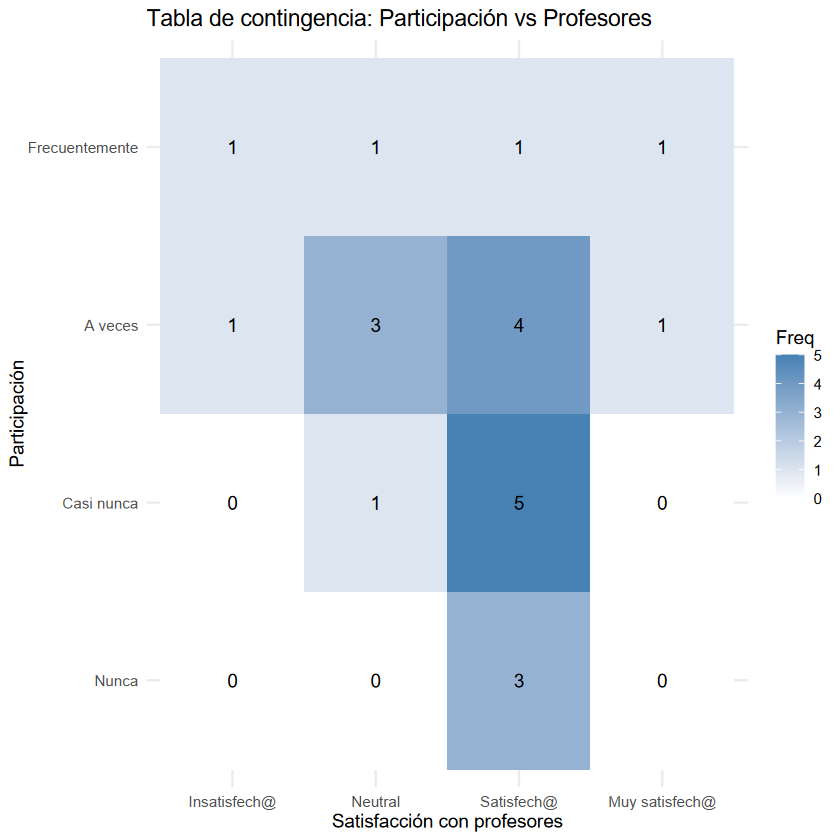

In [13]:
library(ggplot2)

tabla_df <- as.data.frame(tabla)

ggplot(tabla_df, aes(x = Profesores, y = Participacion, fill = Freq)) +
  geom_tile() +
  geom_text(aes(label = Freq)) +
  scale_fill_gradient(low = "white", high = "steelblue") +
  labs(
    title = "Tabla de contingencia: Participación vs Profesores",
    x = "Satisfacción con profesores",
    y = "Participación"
  ) +
  theme_minimal()

Las visualizaciones sugieren que no hay una dependencia.

Y la prueba de tabla de contingencias:

In [14]:
chisq.test(tabla)

Warning message in chisq.test(tabla):
"Chi-squared approximation may be incorrect"



	Pearson's Chi-squared test

data:  tabla
X-squared = 7.7376, df = 9, p-value = 0.5608


Un pvalue de NA es debido a que hay muchas celdas con frecuencia esperada menor a 5, lo cual viola las condiciones de la prueba. 